In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task2.ipynb")

# Homework 3 - Task 2: Tree-Based Methods
## Predicting Water Potability Using Decision Trees and Random Forests

---


### Dataset

Access to safe drinking water is a fundamental public health concern. This dataset contains physicochemical measurements for 3,276 water samples, each labeled as potable or non-potable.

| Feature | Description |
|---|---|
| `ph` | pH value of water (0–14 scale) |
| `Hardness` | Capacity to precipitate soap (mg/L) |
| `Solids` | Total dissolved solids (ppm) |
| `Chloramines` | Amount of chloramines (ppm) |
| `Sulfate` | Amount of sulfates dissolved (mg/L) |
| `Conductivity` | Electrical conductivity (μS/cm) |
| `Organic_carbon` | Amount of organic carbon (ppm) |
| `Trihalomethanes` | Amount of trihalomethanes (μg/L) |
| `Turbidity` | Measure of light-emitting property (NTU) |

#### Response Variable

| Column | Description |
|---|---|
| `Potability` | Binary flag — `1` if water is safe to drink, `0` otherwise |


 **Note:** Several features contain missing values (`ph`, `Sulfate`, `Trihalomethanes`). You will handle these in the preprocessing step.

 This dataset comes from Kaggle and can be found [here](https://www.kaggle.com/datasets/uom190346a/water-quality-and-potability).

### Setup: Load Libraries

Run the cell below to import all required packages.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



### Step 1: Load the Data

Read `water_potability.csv` into a DataFrame. Preview the first few rows and confirm its shape.

In [3]:
df = pd.read_csv('water_potability.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### Step 2: Explore the Data

Before modeling, examine the distribution of your response variable and the number of NAs. Understanding both will guide preprocessing decisions.

In [4]:
print(f'Total NA:', df.isna().sum())
# NA values for sulfate and trihalomethanes

print(f'Data type:', df.dtypes)
# Potability is int

print(f'Unique values:',df['Potability'].unique())
print(f'Value counts:',df['Potability'].value_counts())
# Imbalance categories for potability


Total NA: ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64
Data type: ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object
Unique values: [0 1]
Value counts: Potability
0    1998
1    1278
Name: count, dtype: int64


### Step 3: Preprocess the Data

Three features have missing values. A simple approach for tree-based methods is to **impute with the column median**. Impute the missing values using `df.fillna()`.Store your cleaned dataframe in a variable called `df_clean`. 

After imputation, split the data 70/30 into training and test sets, stratifying on `Potability` to preserve the class ratio in both splits.Store your results in `X_train`, `X_test`, `y_train`, and `y_test`.

In [21]:
# Compute median and fill na
df_clean = df.fillna(df.median())

# From lab
features = [c for c in df_clean.columns if c != 'Potability']
X = df_clean[features]
y = df_clean['Potability']

# test train split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,stratify=y, random_state=42)
print(f"Training samples: {len(X_train):,}  |  Test samples: {len(X_test):,}")


Training samples: 2,293  |  Test samples: 983


In [6]:
grader.check("q1")

q1 results: All test cases passed!

### Step 4: Fit a Single Classification Tree

Start with an **unpruned** classification tree (no constraints on depth or leaf size). This gives a baseline and illustrates the overfitting problem that ensemble methods address.

Fit `DecisionTreeClassifier` with only `random_state=42` set (all other parameters at defaults). Report the tree depth in a variable named `tree_depth`. Calculate both the train accuracy and the test accuracy, storing the train accuracy in a variable called`dt_unpruned_acc_train` and the test accuracy in a variable called `dt_unpruned_acc_test`. 

In [7]:
# Initialize unpruned decision tree with fixed random state
dt_unpruned = DecisionTreeClassifier(random_state=42)

# Fit the tree on training data
dt_unpruned.fit(X_train, y_train)

# Get the depth of the fitted tree
tree_depth = dt_unpruned.get_depth()

# Calculate train and test accuracy
dt_unpruned_acc_train = accuracy_score(y_train, dt_unpruned.predict(X_train))
dt_unpruned_acc_test  = accuracy_score(y_test, dt_unpruned.predict(X_test))

print(f"Untuned tree depth:  {dt_unpruned.get_depth()}")
print(f"Training accuracy:         {dt_unpruned_acc_train:.3f}")
print(f"Test accuracy:             {dt_unpruned_acc_test:.3f}")

Untuned tree depth:  33
Training accuracy:         1.000
Test accuracy:             0.581


In [8]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: How does the training accuracy and test accuracy differ? What does this mean about your model?**

The train accuracy score is at 1, while the test accuracy score is 0.581, this is because the data is overfitting and memorizing the trained data. When it is trained on new data it will perform bad
-- **Question**: If the model is not overfitting, would both the training and test accuracy be 1.0?

<!-- END QUESTION -->

### Step 5: Tune Tree Depth with Cross-Validation

A fully grown tree memorizes the training data (better training accuracy, poor test accuracy). We need to find the right **depth** to prevent this. 

Using 5-fold cross-validation on the training set, compute mean CV accuracy for `max_depth` from 1 to 20. Identify the optimal depth using `np.argmax`, storing it in a variable called `optimal_depth`. Plot the CV Accuracy against the 20 different depths, adding a vertical line at the optimal depth. 

Best max_depth (5-fold CV): 7  (CV accuracy: 0.639)


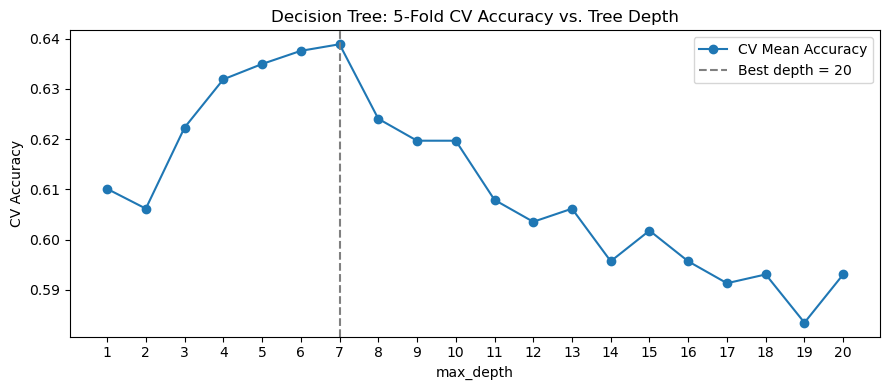

In [11]:

depths = range(1, 21)
cv_means =  []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy')
    cv_means.append(scores.mean())

cv_means = np.array(cv_means)
optimal_depth   = list(depths)[np.argmax(cv_means)]
print(f"Best max_depth (5-fold CV): {optimal_depth}  (CV accuracy: {cv_means.max():.3f})")

plt.figure(figsize=(9, 4))
plt.plot(list(depths), cv_means, label='CV Mean Accuracy', marker='o')
plt.axvline(optimal_depth, color='gray', linestyle='--', label=f'Best depth = {depth}')
plt.xlabel('max_depth')
plt.ylabel('CV Accuracy')
plt.xticks(list(depths))
plt.title('Decision Tree: 5-Fold CV Accuracy vs. Tree Depth')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q2: What did cross fold validation find the optimal depth to be? Explain what these means in plain language.**

a depth of 7, means the tree makes at most 7 splits sequential decisions to classify a water sample. If there is less than 7 splits, it is underfitting which may lead to missing patterns and if its too deep its overfitting. it is getting used to the noise

<!-- END QUESTION -->

### Step 6: Fit the Tuned Decision Tree

Refit the decision tree using `optimal_depth` and evaluate on the held-out test set. Store the test accuracy in a variable called `acc_dt`. 

In [25]:
# Refit Decision Tree with Optimal Depth
dt_opt = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)

# Fit into train data
dt_opt.fit(X_train, y_train)

# Get accuracy score
acc_dt = accuracy_score(y_test, dt_opt.predict(X_test))
print(f'Tuned Decision Tree:', acc_dt)
print(f"Unpruned Test accuracy:   {dt_unpruned_acc_test:.3f}")


Tuned Decision Tree: 0.6459816887080366
Unpruned Test accuracy:   0.581


In [14]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q3: Did the accuracy on your tuned decision tree imrpove compared to your untuned tree? If so, why do you think it improved?**

Yes, The accuracy improved, it was set with the best maximum depth at 7 where the accuracy is 0.6459 when it is tuned. When the decision tree is untuned the accuracy is 0.581. When the tree is unpruned, the is continues to run more splits causing the accuracy to decrease. When tree is tuned, it is able to do its best when it has a limit causing it to stop overfitting.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 7: Visualize the Decision Tree

Plot the tuned tree using `plot_tree`. Save the tree as an image to evaluate the results and answer **Q5**. 

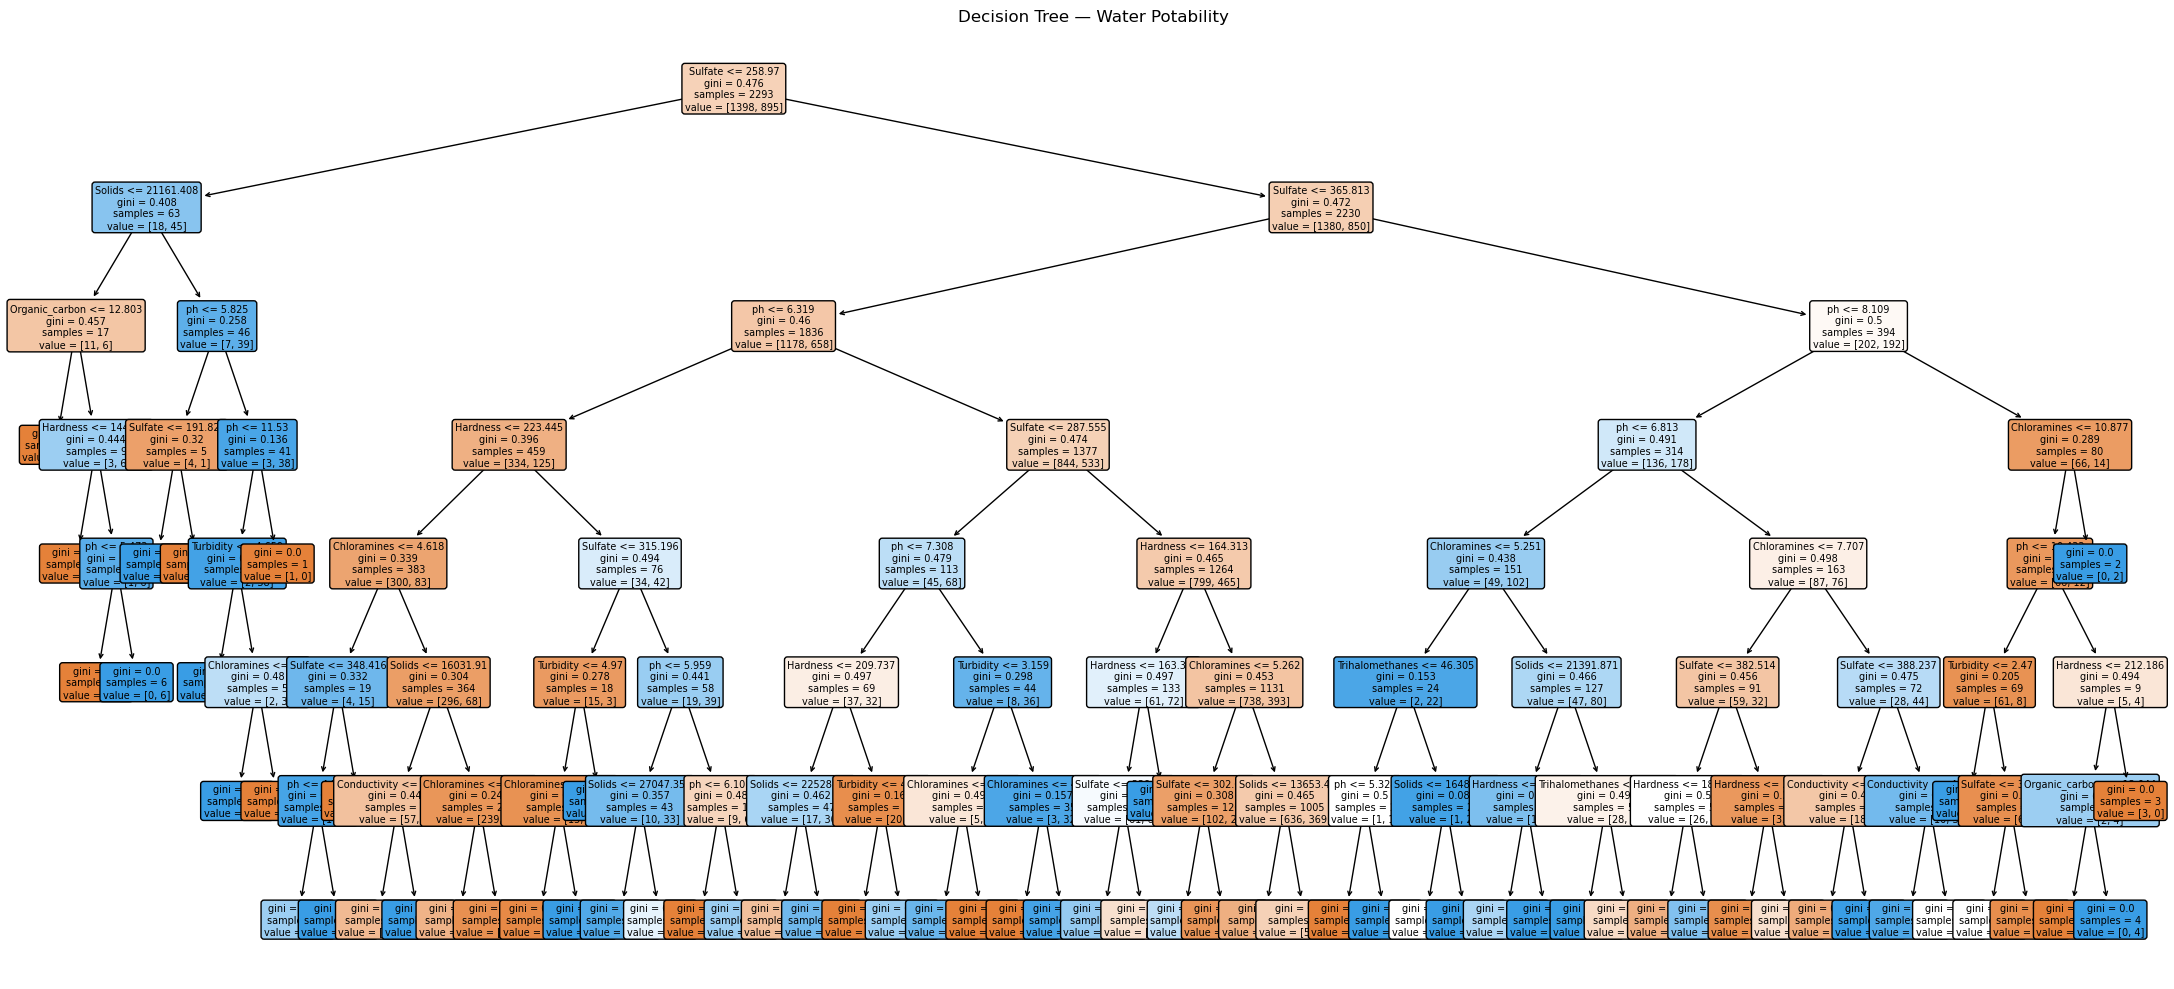

In [15]:
plt.figure(figsize=(22, 10))


plot_tree(dt_opt, feature_names=features,
          filled=True, rounded=True, fontsize=7)

plt.title('Decision Tree — Water Potability')
plt.tight_layout()
plt.show()

> **Q4: Examine the root node and first two levels of the tree. Which feature is used for the root split, and what threshold does it use? What does this tell you about that feature's relationship with potability? What is the Gini impurity at the root, and how does it change after the first split?**

Root split: Sulfate < 258.97, with a Gini = 0.476, this indicated that Sulfate is the most informative predictor for potability. After the first split: Gini decrease from the left 0.408, to the right node 0.472. From the slipt on the right sulfate is actually leans towards non-potable

<!-- END QUESTION -->

### Step 8: Random Forest

**Random forests** address the high variance of a single tree by fitting many trees on bootstrap samples of the training data and averaging their predictions. To further reduce correlation among the trees, at each split only a random subset of $m$ features is considered (by default sklearn uses $m = \lfloor\sqrt{p}\rfloor$ for classification).

Fit a `RandomForestClassifier`, called `rf` with `n_estimators=200`. Report the accuracy and store it in `acc_rf`. 

In [24]:
rf = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs= -1)
rf.fit(X_train, y_train)
acc_rf  = accuracy_score(y_test,  rf.predict(X_test))

print(f' Random Forest Accuracy Score: {acc_rf:.3f}, IS THIS THE ONE THAT WAS MENTIONED IN CLASS?')



 Random Forest Accuracy Score: 0.664, IS THIS THE ONE THAT WAS MENTIONED IN CLASS?


In [19]:
grader.check("q5")

q5 results:
    q5 - 1 result:
        ✅ Test case passed

    q5 - 2 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Expecting nothing
        **********************************************************************
        Line 1, in q5 1
        Failed example:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q5 1[0]>", line 1, in <module>
                assert np.isclose(acc_rf, 0.6612, atol=0.001)
            AssertionError

In [29]:
print(f'Tuned Decision Tree: {acc_dt:.3f}')
print(f"Unpruned Test accuracy:   {dt_unpruned_acc_test:.3f}")
print(f'Random Forest Accuracy Score: {acc_rf:.3f}')


Tuned Decision Tree: 0.646
Unpruned Test accuracy:   0.581
Random Forest Accuracy Score: 0.664


<!-- BEGIN QUESTION -->

>**Q5: Compare the test results of Decision Tree and Random Forest? Which performed beter? Why do you think this is?**

Random forest outperforms decision trees because it does bootstrap sampling (each tree is trained on a different random sample of data) and random feature subset (at each split, only a random subset of features is considered). bootstrapping and random feature subset, reduce correlation between trees, averaging their predictions cancels out errors and improves generlizability

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 9: Feature Importances

Both decision trees and random forests assign an **importance score** to each feature based on the total reduction in impurity (Gini) it produces across all splits. Random forest importances are averaged over all trees in the ensemble, making them more stable than a single tree's importances.

Create a bar plot showing the feature importances from the tuned decision tree and the random forest side by side. You can access the feature importants from the model wtih `model.feature_importances_`.

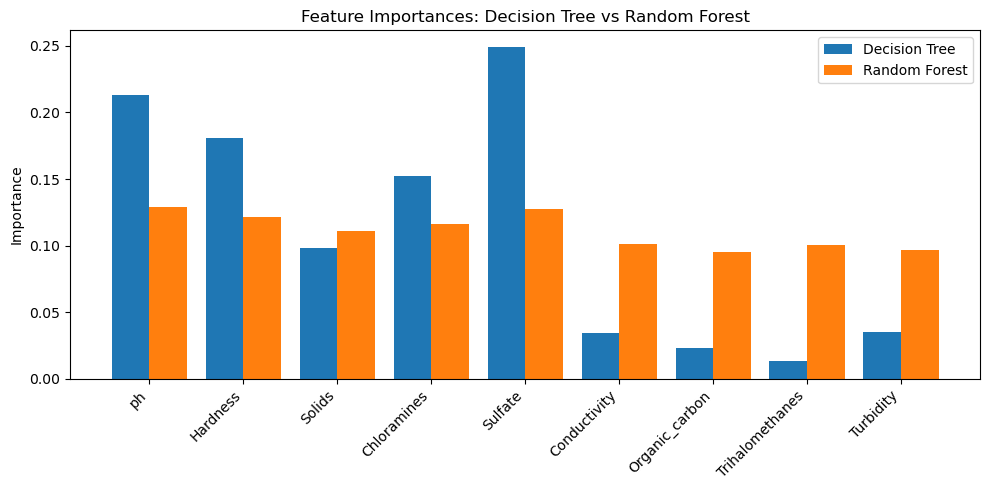

In [ ]:


features = X_train.columns
x = np.arange(len(features))
width = 0.4

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, dt_opt.feature_importances_, width, label='Decision Tree')
ax.bar(x + width/2, rf.feature_importances_,     width, label='Random Forest')

ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha='right')
ax.set_ylabel('Variable Importance')
ax.set_title('Feature Importances: Decision Tree v Random Forest')
ax.legend()
plt.tight_layout()
plt.show()



> **Q6: Do the decision tree and random forest agree on which features are most important? If they differ, why might a single tree's importances be less reliable than the random forest's? Which feature appears most important for predicting potability, and does that make physical sense?**

Yes, both decision tree and random forest agree on the features Sulfate and pH to be the most important features. 
For the decision tree, a tree has a single strong predictor dominate every tree, it always gets first pick at every split. 
In a random forest, feature subsets prevents any predictor from dominating, so importances are more evenly spread and reliable. This allows for a more diverse tree. That is where the fresh random subset comes into play.
Yes it makes sense that sulface and pH are the most imporatnt features to check potable water. pH helps measures how acidic or alkaline your water is on a scale and sulfate shows how much mineral salt is in the water determining the taste of the water

<!-- END QUESTION -->

### Step 10: Confusion Matrix

Create a confusion matrix for the random forest model using `ConfusionMatrixDisplay`. Label your response variable as `Not Potable`/ `Potable` in the confusion matrix (instead of `0`/`1`).

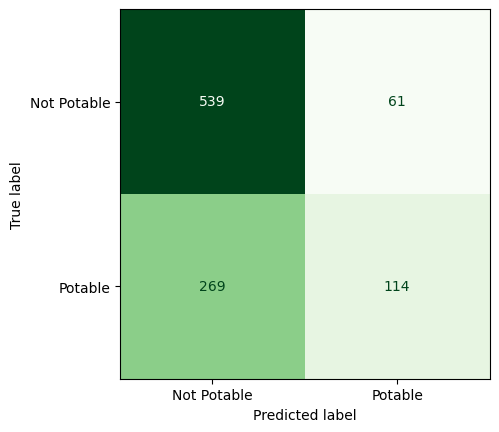

In [31]:
# Confusion Matrix 
ConfusionMatrixDisplay.from_estimator(
    rf, X_test, y_test,
    display_labels=['Not Potable', 'Potable'],
    cmap='Greens',
    colorbar=False,
)


<!-- BEGIN QUESTION -->

> **Q7:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

There are 114 true positives, meaning that potable water was correctly identified.
There are 539 true negative, meaning that not potable water was correctly identified.
There are 269 False positive: potable water was labeled as not potable water
There are 61 False negative: not potable water was incorrectly labeled as potable water. Having False negatives is dangerous because people will drink not potable water without knowing.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 11: Model Comparison

Create a table or bar chart comparing test accuracy across all three models.

In [35]:
    # Table comparing test accuracy of all models 
pd.DataFrame({
    'Model': ['Unpruned Tree', 'Tuned Tree', 'Random Forest'],
    'Test Accuracy': [dt_unpruned_acc_test, acc_dt, acc_rf],
})

print(f'difference between pruned and unpruned tree: {acc_dt-dt_unpruned_acc_test:.3f}')


difference between pruned and unpruned tree: 0.065


> **Q8:** Which model achieved the highest test accuracy? Comparing the unpruned and tuned decision tree, how much did pruning improve accuracy? What does this tell you about overfitting in the unpruned tree?


The highest test accuracy is random forest. Pruning the decision tree improved the accuracy by approximately by 0.065. In the unpruned tree we are overfitting meaning that the data will fit perfectly in the training data but generalize poorly to new observations. As the tree grows deeper the decision boundaries become increasingly specific to the training data

---

Run the cell below to receive credit for autograded questions. 

In [36]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results:
    q5 - 1 result:
        ✅ Test case passed

    q5 - 2 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Expecting nothing
        **********************************************************************
        Line 1, in q5 1
        Failed example:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q5 1[0]>", line 1, in <module>
                assert np.isclose(acc_rf, 0.6612, atol=0.001)
            AssertionError